In [ ]:
!pip install -q sentence-transformers==3.3.1
!pip install -q datasets
!pip install -q accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json
import os

modelSaveDir = "/content/drive/MyDrive/Bitirme_Projesi"
datasetPath = "/content/drive/MyDrive/PDF_Library/squad_dataset.json"

os.makedirs(modelSaveDir, exist_ok=True)

with open(datasetPath, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

print("DATASET")

print(f"\nTop-level keys: {list(raw_data.keys())}")

if "data" not in raw_data:
    print("UYARI: 'data' key'i bulunamadı. SQuAD formatı olmayabilir.")
else:
    print(f"Toplam doküman/title sayısı: {len(raw_data['data'])}")

# STATISTICS
total_paragraphs = 0
total_questions = 0
total_answers = 0
impossible_count = 0
context_lengths = []
question_lengths = []
answer_lengths = []
empty_answers = 0

for doc in raw_data["data"]:
    for paragraph in doc.get("paragraphs", []):
        total_paragraphs += 1
        context = paragraph.get("context", "")
        context_lengths.append(len(context))

        for qa in paragraph.get("qas", []):
            total_questions += 1
            question_lengths.append(len(qa.get("question", "")))

            if qa.get("is_impossible", False):
                impossible_count += 1

            answers = qa.get("answers", [])
            if not answers:
                empty_answers += 1
            else:
                total_answers += len(answers)
                for ans in answers:
                    answer_lengths.append(len(ans.get("text", "")))


print("\nİSTATİSTİKLER")

print(f"Toplam paragraf (context) sayısı : {total_paragraphs}")
print(f"Toplam soru sayısı               : {total_questions}")
print(f"Toplam cevap sayısı              : {total_answers}")
print(f"Cevabı olmayan soru sayısı       : {empty_answers}")
print(f"'is_impossible=True' soru sayısı : {impossible_count}")

def stats(name, lst):
    if not lst:
        print(f"{name}: veri yok")
        return
    print(f"{name}: min={min(lst)}, max={max(lst)}, ortalama={sum(lst)/len(lst):.1f}")

print()
stats("Context uzunluğu (karakter)", context_lengths)
stats("Soru uzunluğu (karakter)", question_lengths)
stats("Cevap uzunluğu (karakter)", answer_lengths)

print("\nÖRNEK KAYIT")

first_doc = raw_data["data"][0]
first_para = first_doc["paragraphs"][0]
first_qa = first_para["qas"][0]

print(f"Title: {first_doc.get('title', '(yok)')}")
print(f"\nContext (ilk 300 karakter):\n{first_para['context'][:300]}...")
print(f"\nSoru: {first_qa['question']}")
print(f"Cevap: {first_qa['answers']}")
print(f"is_impossible: {first_qa.get('is_impossible', 'belirtilmemiş')}")

DATASET

Top-level keys: ['version', 'data']
Toplam doküman/title sayısı: 329

İSTATİSTİKLER
Toplam paragraf (context) sayısı : 1621
Toplam soru sayısı               : 7194
Toplam cevap sayısı              : 7194
Cevabı olmayan soru sayısı       : 0
'is_impossible=True' soru sayısı : 0

Context uzunluğu (karakter): min=782, max=1200, ortalama=1194.7
Soru uzunluğu (karakter): min=13, max=213, ortalama=67.3
Cevap uzunluğu (karakter): min=1, max=454, ortalama=43.3

ÖRNEK KAYIT
Title: 145_perceptions-of-artificial-intelligence-among-healthcare-staff-a-qualitative-survey-study.pdf

Context (ilk 300 karakter):
Perceptions of Artiﬁcial Intelligence Among Healthcare Staff: A Qualitative Survey Study Simone Castagno* and Mohamed Khalifa Department of Interventional Radiology, Royal Free Hospital, London, United Kingdom Objectives: The medical community is in agreement that artiﬁcial intelligence (AI) will ha...

Soru: What is the primary objective of the study mentioned in the text?
Cevap: [{'t

In [ ]:
# SQuAD formatını (question, context) çiftlerine dönüştür
qa_pairs = []

for doc in raw_data["data"]:
    for paragraph in doc["paragraphs"]:
        context = paragraph["context"]
        for qa in paragraph["qas"]:
            qa_pairs.append({
                "question": qa["question"],
                "context": context,
            })

print(f"Toplam çift sayısı: {len(qa_pairs)}")
print()
print(f"Ornek cift:")
print(f"Q: {qa_pairs[0]['question']}")
print(f"C: {qa_pairs[0]['context'][:200]}...")

# Duplicate kontrolu
unique_questions = set(p["question"] for p in qa_pairs)
unique_contexts = set(p["context"] for p in qa_pairs)

print()
print(f"Essiz soru sayisi   : {len(unique_questions)}")
print(f"Essiz context sayisi: {len(unique_contexts)}")
print(f"Context basina ortalama soru: {len(qa_pairs) / len(unique_contexts):.2f}")

Toplam çift sayısı: 7194

Ornek cift:
Q: What is the primary objective of the study mentioned in the text?
C: Perceptions of Artiﬁcial Intelligence Among Healthcare Staff: A Qualitative Survey Study Simone Castagno* and Mohamed Khalifa Department of Interventional Radiology, Royal Free Hospital, London, Unite...

Essiz soru sayisi   : 5449
Essiz context sayisi: 1059
Context basina ortalama soru: 6.79


In [ ]:
import random
from collections import defaultdict

random.seed(42)

# Her Context ona ait soru listesi
context_to_questions = defaultdict(list)
for pair in qa_pairs:
    context_to_questions[pair["context"]].append(pair["question"])

all_contexts = list(context_to_questions.keys())
random.shuffle(all_contexts)

# Context'leri ayir (soruları degil)
val_ratio = 0.1
val_size = int(len(all_contexts) * val_ratio)

val_contexts = set(all_contexts[:val_size])
train_contexts = set(all_contexts[val_size:])

# Sorulari ilgili context'lere gore ayir
train_pairs = [p for p in qa_pairs if p["context"] in train_contexts]
val_pairs = [p for p in qa_pairs if p["context"] in val_contexts]

print(f"Train context sayisi: {len(train_contexts)}")
print(f"Val context sayisi  : {len(val_contexts)}")
print()
print(f"Train pair sayisi   : {len(train_pairs)}")
print(f"Val pair sayisi     : {len(val_pairs)}")

# Leakage kontrolu
train_ctx_set = set(p["context"] for p in train_pairs)
val_ctx_set = set(p["context"] for p in val_pairs)
overlap = train_ctx_set & val_ctx_set

print()
print(f"Train-Val context overlap: {len(overlap)}  (0 olmali)")

Train context sayisi: 954
Val context sayisi  : 105

Train pair sayisi   : 6515
Val pair sayisi     : 679

Train-Val context overlap: 0  (0 olmali)


In [ ]:
# Train setinde duplicate soruları temizle
seen_questions = set()
train_pairs_dedup = []

for pair in train_pairs:
    if pair["question"] not in seen_questions:
        seen_questions.add(pair["question"])
        train_pairs_dedup.append(pair)

print(f"Train pair (dedup oncesi): {len(train_pairs)}")
print(f"Train pair (dedup sonrasi): {len(train_pairs_dedup)}")
print(f"Cikarilan duplicate: {len(train_pairs) - len(train_pairs_dedup)}")

# Val'da deduplicate'e gerek yok (evaluation'da sorun olmaz)
# Ama yine de bakalim
val_unique_q = len(set(p["question"] for p in val_pairs))
print()
print(f"Val pair: {len(val_pairs)}, essiz soru: {val_unique_q}")

Train pair (dedup oncesi): 6515
Train pair (dedup sonrasi): 4929
Cikarilan duplicate: 1586

Val pair: 679, essiz soru: 542


In [ ]:
from datasets import Dataset

# Sentence-transformers konvansiyonu:
# ilk column = anchor (sorgu), ikinci column = positive (pozitif eslesme)
train_data = {
    "anchor": [p["question"] for p in train_pairs_dedup],
    "positive": [p["context"] for p in train_pairs_dedup],
}

val_data = {
    "anchor": [p["question"] for p in val_pairs],
    "positive": [p["context"] for p in val_pairs],
}

train_dataset = Dataset.from_dict(train_data)
val_dataset = Dataset.from_dict(val_data)

print(f"Train dataset: {train_dataset}")
print(f"Val dataset  : {val_dataset}")
print()
print("Ornek train kaydi:")
print(f"anchor  : {train_dataset[0]['anchor']}")
print(f"positive: {train_dataset[0]['positive'][:150]}...")

Train dataset: Dataset({
    features: ['anchor', 'positive'],
    num_rows: 4929
})
Val dataset  : Dataset({
    features: ['anchor', 'positive'],
    num_rows: 679
})

Ornek train kaydi:
anchor  : What is the primary objective of the study mentioned in the text?
positive: Perceptions of Artiﬁcial Intelligence Among Healthcare Staff: A Qualitative Survey Study Simone Castagno* and Mohamed Khalifa Department of Interventi...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Question - mean:17  p90:23  p95:25  max:52
Context  - mean:283  p90:337  p95:368  max:681

QUERY_MAX_LEN   = 32
PASSAGE_MAX_LEN = 384


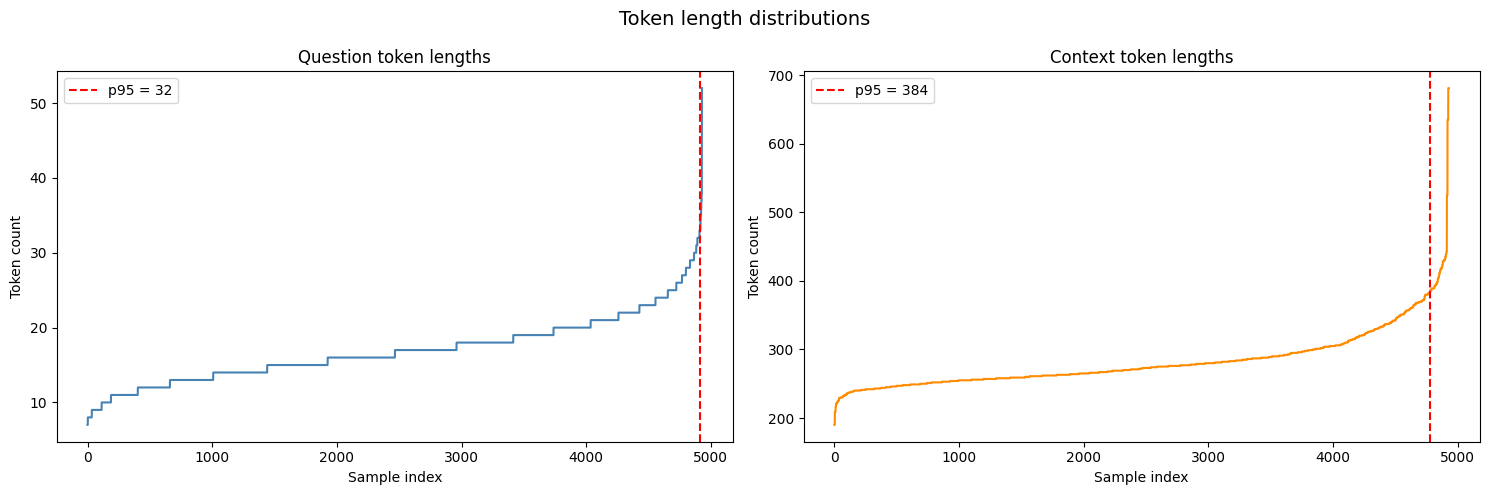

In [ ]:
from transformers import AutoTokenizer
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np

tqdm.pandas()

tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")

# Train set uzerinde token uzunluklari hesapla
question_lens = [len(tokenizer(p["question"])["input_ids"]) for p in train_pairs_dedup]
context_lens  = [len(tokenizer(p["context"])["input_ids"])  for p in train_pairs_dedup]

question_lens = np.array(question_lens)
context_lens  = np.array(context_lens)

def round_to_32(n):
    return int(((n + 31) // 32) * 32)

QUERY_MAX_LEN   = round_to_32(int(np.quantile(question_lens, 0.95)))
PASSAGE_MAX_LEN = round_to_32(int(np.quantile(context_lens, 0.95)))

print(f"Question - mean:{question_lens.mean():.0f}  p90:{np.quantile(question_lens, 0.90):.0f}  p95:{np.quantile(question_lens, 0.95):.0f}  max:{question_lens.max()}")
print(f"Context  - mean:{context_lens.mean():.0f}  p90:{np.quantile(context_lens, 0.90):.0f}  p95:{np.quantile(context_lens, 0.95):.0f}  max:{context_lens.max()}")
print(f"\nQUERY_MAX_LEN   = {QUERY_MAX_LEN}")
print(f"PASSAGE_MAX_LEN = {PASSAGE_MAX_LEN}")

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
fig.suptitle("Token length distributions", fontsize=14)

sorted_q = np.sort(question_lens)
ax1.plot(sorted_q, color="steelblue")
ax1.axvline(x=(question_lens <= QUERY_MAX_LEN).sum(), color="red", linestyle="--", label=f"p95 = {QUERY_MAX_LEN}")
ax1.set_title("Question token lengths")
ax1.set_xlabel("Sample index")
ax1.set_ylabel("Token count")
ax1.legend()

sorted_c = np.sort(context_lens)
ax2.plot(sorted_c, color="darkorange")
ax2.axvline(x=(context_lens <= PASSAGE_MAX_LEN).sum(), color="red", linestyle="--", label=f"p95 = {PASSAGE_MAX_LEN}")
ax2.set_title("Context token lengths")
ax2.set_xlabel("Sample index")
ax2.set_ylabel("Token count")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer
import torch

model = SentenceTransformer("BAAI/bge-m3")

print(f"Model: BAAI/bge-m3")
print(f"Max seq length: {model.max_seq_length}")
print(f"Embedding dim : {model.get_sentence_embedding_dimension()}")
print(f"Device        : {model.device}")
print(f"GPU available : {torch.cuda.is_available()}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Model: BAAI/bge-m3
Max seq length: 8192
Embedding dim : 1024
Device        : cuda:0
GPU available : True


In [ ]:
model.max_seq_length = max(QUERY_MAX_LEN, PASSAGE_MAX_LEN)
print(f"Model max_seq_length ayarlandi: {model.max_seq_length}")

Model max_seq_length ayarlandi: 384


In [ ]:
import torch
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

val_questions = [p["question"] for p in val_pairs]
val_contexts  = [p["context"]  for p in val_pairs]

def encode_batched(st_model, texts, batch_size=32):
    return st_model.encode(
        texts,
        normalize_embeddings=True,
        convert_to_tensor=True,
        batch_size=batch_size,
        show_progress_bar=True,
        device=device,
    ).cpu()

print("Baseline (fine-tune oncesi) embedding hesaplaniyor...")
base_q_embs = encode_batched(model, val_questions)
base_c_embs = encode_batched(model, val_contexts)

base_pos_sims = (base_q_embs * base_c_embs).sum(dim=1).numpy()

rng = np.random.default_rng(42)
shuffle_idx = rng.permutation(len(val_questions))
base_neg_sims = (base_q_embs * base_c_embs[shuffle_idx]).sum(dim=1).numpy()

print(f"\nBaseline cosine similarity:")
print(f"  Positive (dogru eslesme) : mean={base_pos_sims.mean():.4f}  std={base_pos_sims.std():.4f}")
print(f"  Negative (rastgele)      : mean={base_neg_sims.mean():.4f}  std={base_neg_sims.std():.4f}")
print(f"  Delta (pos - neg)        : {base_pos_sims.mean() - base_neg_sims.mean():.4f}")

corpus_texts = list(set(val_contexts))
corpus_map = {ctx: i for i, ctx in enumerate(corpus_texts)}

print(f"\nCorpus boyutu: {len(corpus_texts)} essiz context")
print("Corpus embeddings hesaplaniyor...")
base_corpus_embs = encode_batched(model, corpus_texts)

def recall_at_k(q_embs, c_embs, correct_idx, k_values):
    scores = q_embs @ c_embs.T
    results = {}
    for k in k_values:
        top_k = scores.topk(k, dim=1).indices.numpy()
        hits = sum(correct_idx[i] in top_k[i] for i in range(len(correct_idx)))
        results[k] = hits / len(correct_idx)
    return results

K_VALUES = [1, 3, 5, 10, 20]
correct_idx = [corpus_map[ctx] for ctx in val_contexts]
base_recall = recall_at_k(base_q_embs, base_corpus_embs, correct_idx, K_VALUES)

print(f"\nBaseline Recall@k:")
for k in K_VALUES:
    print(f"  @{k:<3}: {base_recall[k]:.4f}")

Baseline (fine-tune oncesi) embedding hesaplaniyor...


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]


Baseline cosine similarity:
  Positive (dogru eslesme) : mean=0.5626  std=0.0951
  Negative (rastgele)      : mean=0.4137  std=0.0904
  Delta (pos - neg)        : 0.1488

Corpus boyutu: 105 essiz context
Corpus embeddings hesaplaniyor...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]


Baseline Recall@k:
  @1  : 0.6406
  @3  : 0.7865
  @5  : 0.8277
  @10 : 0.8719
  @20 : 0.9308


In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from sentence_transformers import SentenceTransformer, SentenceTransformerTrainer, SentenceTransformerTrainingArguments
from sentence_transformers.losses import MultipleNegativesRankingLoss
from transformers import TrainerCallback

model = SentenceTransformer("BAAI/bge-m3")
model.max_seq_length = 384

# Gradient checkpointing — belleği %30-40 düşürür
model[0].auto_model.gradient_checkpointing_enable()

print(f"Model yuklendi, max_seq_length={model.max_seq_length}")
print("Gradient checkpointing aktif")

loss_fn = MultipleNegativesRankingLoss(model)

output_dir = os.path.join(modelSaveDir, "bge-m3-finetuned")

training_args = SentenceTransformerTrainingArguments(
    output_dir=output_dir,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    fp16=True,
    logging_steps=20,
    save_strategy="epoch",
    save_total_limit=2,
    report_to="none",
    dataloader_num_workers=2,
    gradient_checkpointing=True,
)

loss_log = []

class LossLogger(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            loss_log.append({"step": state.global_step, "loss": logs["loss"]})

trainer = SentenceTransformerTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    loss=loss_fn,
    callbacks=[LossLogger()],
)

print("Training basladi...")
trainer.train()

print("\nTraining tamamlandi.")
print(f"Toplam step: {len(loss_log)}")
print(f"Ilk loss    : {loss_log[0]['loss']:.4f}")
print(f"Son loss    : {loss_log[-1]['loss']:.4f}")
print(f"En iyi loss : {min(e['loss'] for e in loss_log):.4f}")

model.save(output_dir)
print(f"\nModel kaydedildi: {output_dir}")

Model yuklendi, max_seq_length=384
Gradient checkpointing aktif
Training basladi...


Step,Training Loss
20,0.314100
40,0.161900
60,0.171000
80,0.164800
100,0.136200
120,0.119500
140,0.140600
160,0.082000
180,0.053800
200,0.098800


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]


Training tamamlandi.
Toplam step: 23
Ilk loss    : 0.3141
Son loss    : 0.0489
En iyi loss : 0.0389

Model kaydedildi: /content/drive/MyDrive/Bitirme_Projesi/bge-m3-finetuned


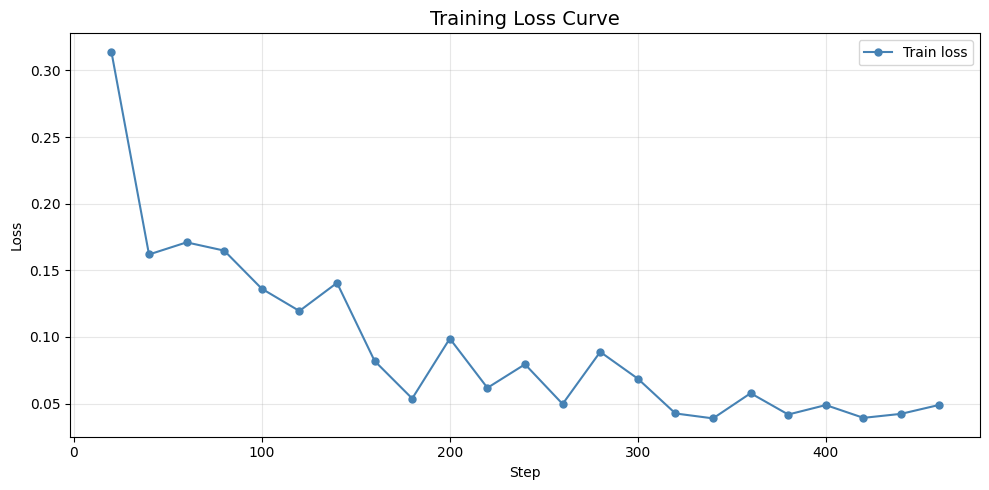

Ilk loss    : 0.3141
Son loss    : 0.0489
En iyi loss : 0.0389  (step 340)
Toplam log  : 23 adim


In [ ]:
import matplotlib.pyplot as plt

if loss_log:
    steps = [e["step"] for e in loss_log]
    losses_vals = [e["loss"] for e in loss_log]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(steps, losses_vals, marker="o", markersize=5, linewidth=1.5,
            color="steelblue", label="Train loss")
    ax.set_title("Training Loss Curve", fontsize=14)
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    best_step = steps[losses_vals.index(min(losses_vals))]
    print(f"Ilk loss    : {losses_vals[0]:.4f}")
    print(f"Son loss    : {losses_vals[-1]:.4f}")
    print(f"En iyi loss : {min(losses_vals):.4f}  (step {best_step})")
    print(f"Toplam log  : {len(losses_vals)} adim")
else:
    print("loss_log bos — LossLogger callback calismami olabilir.")

In [ ]:
print("Fine-tuned model ile embeddings hesaplaniyor...")
ft_q_embs = encode_batched(model, val_questions)
ft_c_embs = encode_batched(model, val_contexts)

ft_pos_sims = (ft_q_embs * ft_c_embs).sum(dim=1).numpy()
ft_neg_sims = (ft_q_embs * ft_c_embs[shuffle_idx]).sum(dim=1).numpy()

print(f"\nFine-tuned cosine similarity:")
print(f"  Positive : mean={ft_pos_sims.mean():.4f}  std={ft_pos_sims.std():.4f}")
print(f"  Negative : mean={ft_neg_sims.mean():.4f}  std={ft_neg_sims.std():.4f}")
print(f"  Delta    : {ft_pos_sims.mean() - ft_neg_sims.mean():.4f}")

print("\nFine-tuned corpus embeddings hesaplaniyor...")
ft_corpus_embs = encode_batched(model, corpus_texts)

ft_recall = recall_at_k(ft_q_embs, ft_corpus_embs, correct_idx, K_VALUES)

print(f"\nRecall@k Karsilatirma:")
print(f"{'k':<6} {'Base':>10} {'Fine-tuned':>12} {'Delta':>10}")
print("-" * 40)
for k in K_VALUES:
    delta = ft_recall[k] - base_recall[k]
    print(f"@{k:<5} {base_recall[k]:>10.4f} {ft_recall[k]:>12.4f} {delta:>+10.4f}")

Fine-tuned model ile embeddings hesaplaniyor...


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]


Fine-tuned cosine similarity:
  Positive : mean=0.3877  std=0.1172
  Negative : mean=0.0257  std=0.1161
  Delta    : 0.3620

Fine-tuned corpus embeddings hesaplaniyor...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]


Recall@k Karsilatirma:
k            Base   Fine-tuned      Delta
----------------------------------------
@1         0.6406       0.7482    +0.1075
@3         0.7865       0.8778    +0.0913
@5         0.8277       0.9264    +0.0987
@10        0.8719       0.9602    +0.0884
@20        0.9308       0.9926    +0.0619


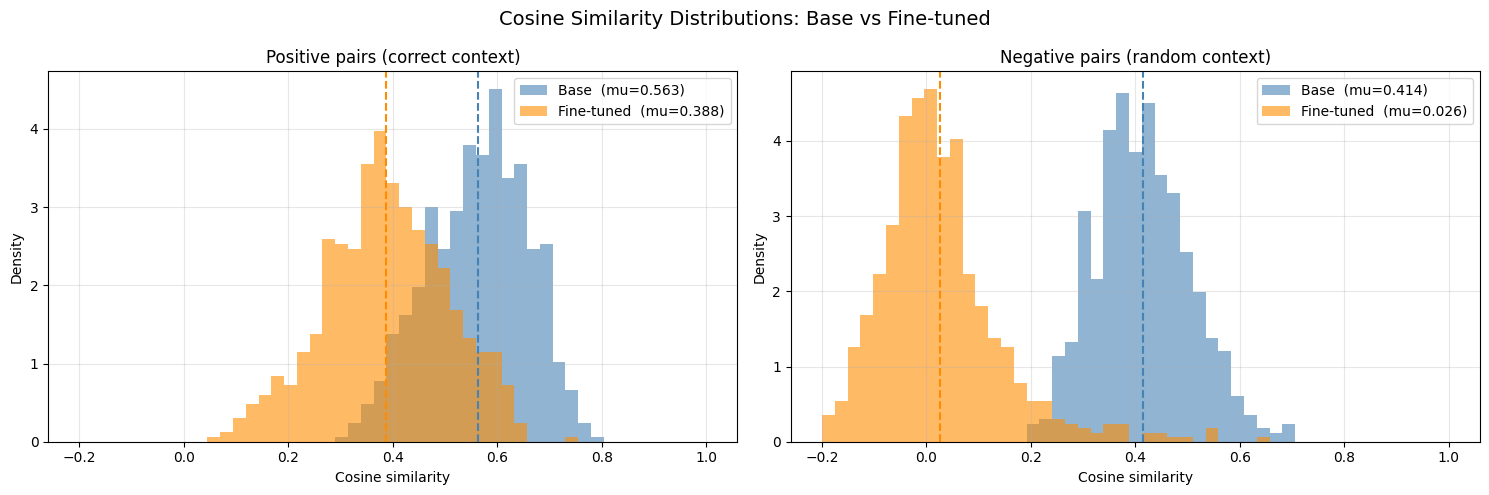

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Cosine Similarity Distributions: Base vs Fine-tuned", fontsize=14)

bins = np.linspace(-0.2, 1.0, 50)

for ax, (base_sims, ft_sims, label) in zip(axes, [
    (base_pos_sims, ft_pos_sims, "Positive pairs (correct context)"),
    (base_neg_sims, ft_neg_sims, "Negative pairs (random context)"),
]):
    ax.hist(base_sims, bins=bins, alpha=0.6, color="steelblue",
            label=f"Base  (mu={base_sims.mean():.3f})", density=True)
    ax.hist(ft_sims, bins=bins, alpha=0.6, color="darkorange",
            label=f"Fine-tuned  (mu={ft_sims.mean():.3f})", density=True)
    ax.axvline(base_sims.mean(), color="steelblue", linestyle="--", linewidth=1.5)
    ax.axvline(ft_sims.mean(), color="darkorange", linestyle="--", linewidth=1.5)
    ax.set_title(label)
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

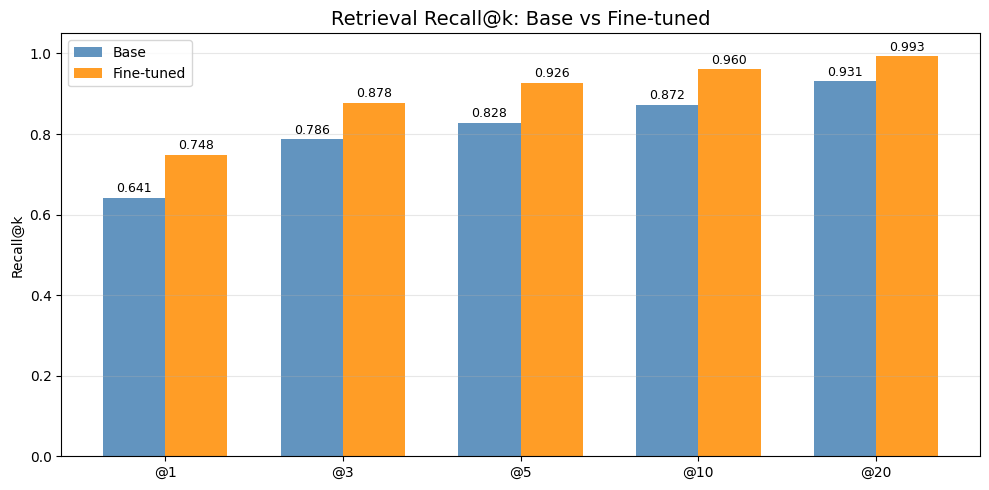

In [ ]:
x = np.arange(len(K_VALUES))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, [base_recall[k] for k in K_VALUES], w,
            label="Base", color="steelblue", alpha=0.85)
b2 = ax.bar(x + w/2, [ft_recall[k] for k in K_VALUES], w,
            label="Fine-tuned", color="darkorange", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f"@{k}" for k in K_VALUES])
ax.set_ylabel("Recall@k")
ax.set_title("Retrieval Recall@k: Base vs Fine-tuned", fontsize=14)
ax.legend()
ax.set_ylim(0, 1.05)
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=9)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()